<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/B2_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
print("All libraries are loaded")

All libraries are loaded


# Load the data

In [ ]:
df = pd.read_csv("/content/mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.shape

(200, 5)

In [ ]:
print("Dataser Summary")
print("="*50)
print(df.describe().round(1))


Dataser Summary
       CustomerID    Age  Annual Income (k$)  Spending Score (1-100)
count       200.0  200.0               200.0                   200.0
mean        100.5   38.8                60.6                    50.2
std          57.9   14.0                26.3                    25.8
min           1.0   18.0                15.0                     1.0
25%          50.8   28.8                41.5                    34.8
50%         100.5   36.0                61.5                    50.0
75%         150.2   49.0                78.0                    73.0
max         200.0   70.0               137.0                    99.0


In [ ]:
df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


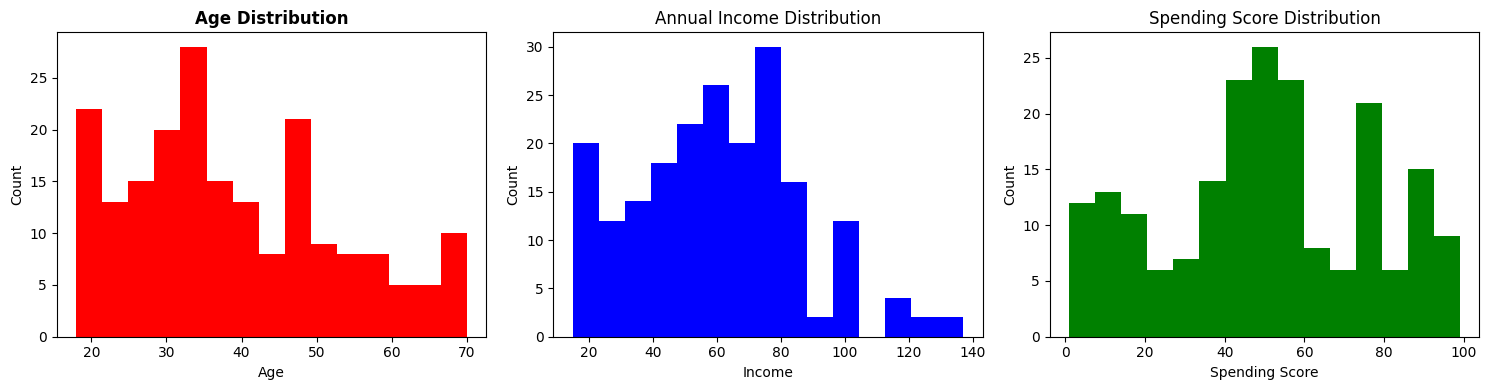

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Age'], bins=15, color='red')
axes[0].set_title('Age Distribution', fontweight = 'bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df['Annual Income (k$)'], bins=15, color='blue')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Count')

axes[2].hist(df['Spending Score (1-100)'], bins=15, color='green')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

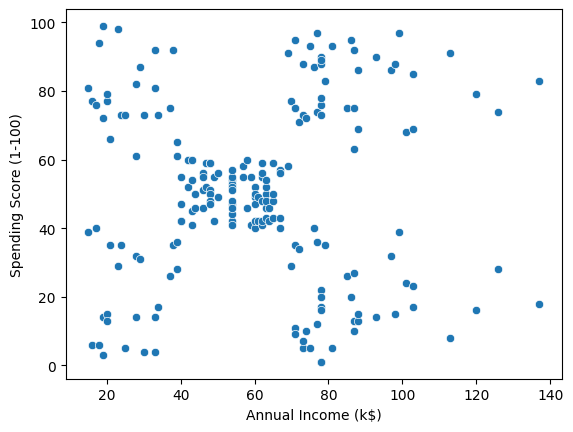

In [ ]:
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = df)

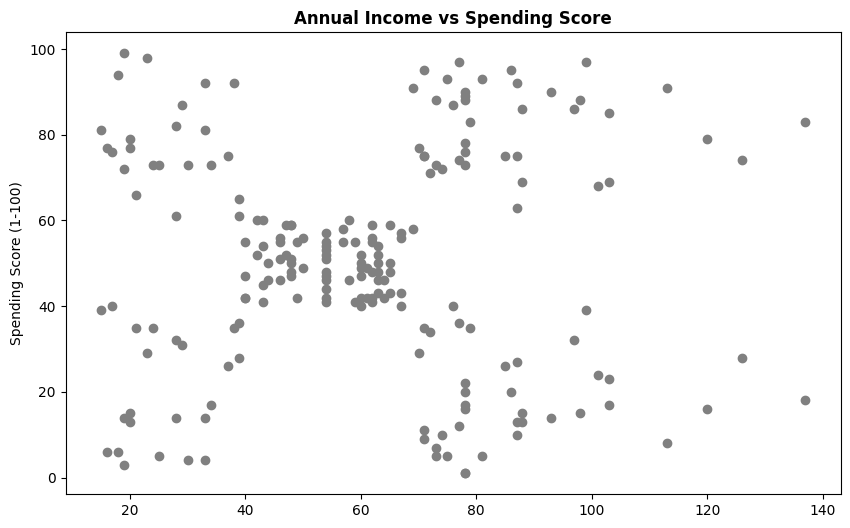

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color = 'grey')
plt.title('Annual Income vs Spending Score', fontweight = 'bold')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Prepare the data for the K meanss clustering technique

In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(f"features: Income and spending score")
print(X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


features: Income and spending score
(200, 2)


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
K = 5

km = KMeans(n_clusters=K, random_state = 42, n_init = 'auto')
km.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [ ]:
km.labels_

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
print(silhouette_score(X_scaled, km.labels_))

0.5546571631111091


# Run this code in a loop

In [ ]:
K_range = range(2, 11)
silhouette_scores = []

for k in K_range:
  km = KMeans(n_clusters=k, random_state = 42, n_init='auto')
  km.fit(X_scaled)
  silhouette_scores.append(silhouette_score(X_scaled, km.labels_))


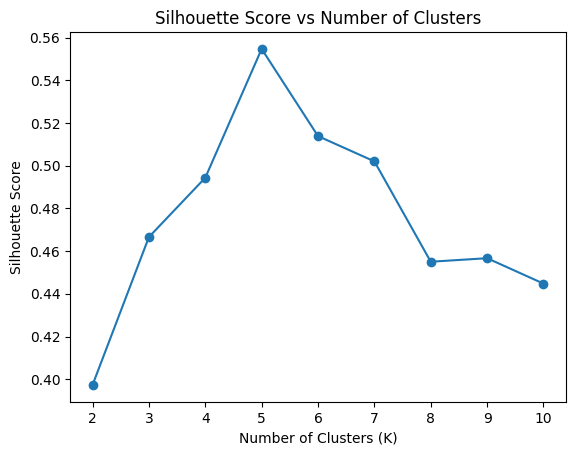

In [ ]:
plt.plot(K_range, silhouette_scores, marker = 'o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

# Fit the final model with the best K value

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
kmeans.fit(X_scaled)